In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


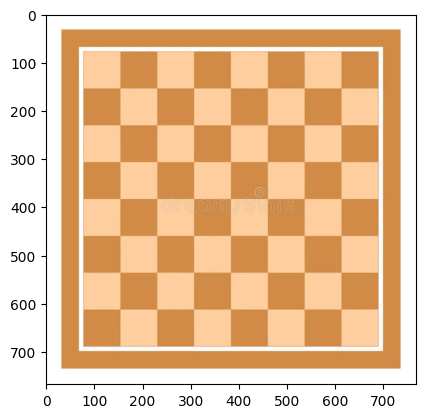

In [11]:
# Load the chessboard image and convert it to RGB format
chessBoard = cv2.imread('../images/chessBoard.png')
chessBoard = cv2.cvtColor(chessBoard, cv2.COLOR_BGR2RGB)
plt.imshow(chessBoard)

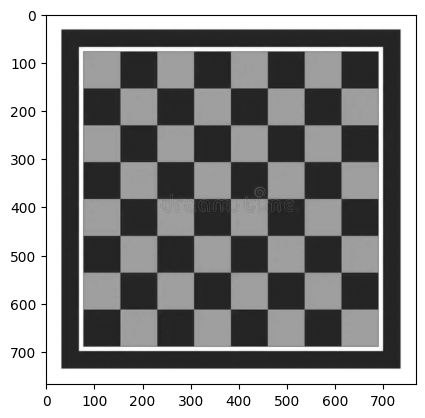

In [12]:
# Convert the image to grayscale
gray_chessBoard = cv2.cvtColor(chessBoard, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_chessBoard, cmap='gray')


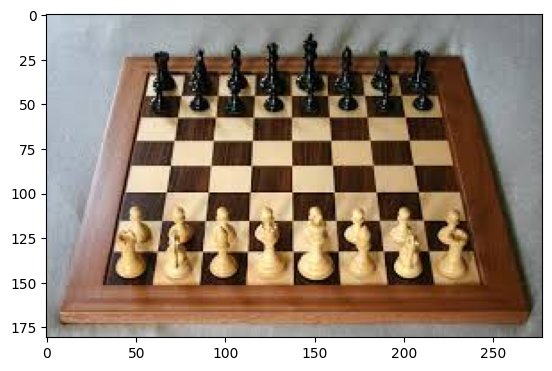

In [13]:
real_chessBoard = cv2.imread('../images/real_chessBoard.jpg')
real_chessBoard = cv2.cvtColor(real_chessBoard, cv2.COLOR_BGR2RGB)
plt.imshow(real_chessBoard)

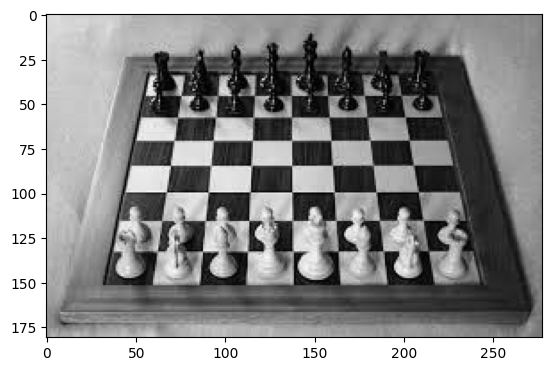

In [14]:
gray_real_chessBoard = cv2.cvtColor(real_chessBoard, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_real_chessBoard, cmap='gray')

In [15]:
# Convert the grayscale image to float32
gray = np.float32(gray_chessBoard)
gray

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]],
      shape=(768, 768), dtype=float32)

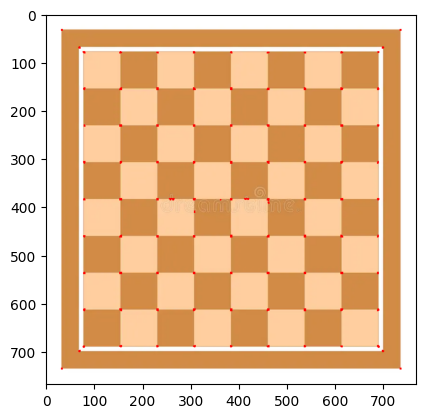

In [16]:
# Apply the Harris corner detection algorithm
gray = np.float32(gray_chessBoard)
dst =   cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)
dst = cv2.dilate(dst, None)
chessBoard[dst > 0.01 * dst.max()] = [255, 0, 0]
plt.imshow(chessBoard)

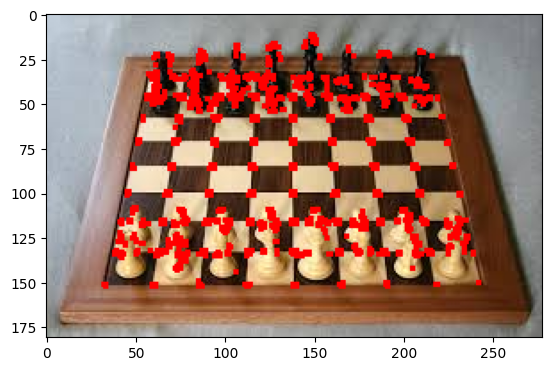

In [17]:
# Apply the Harris corner detection algorithm
gray = np.float32(gray_real_chessBoard)
dst =   cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)
dst = cv2.dilate(dst, None)
# Mark the corners in the original image
real_chessBoard[dst > 0.01 * dst.max()] = [255, 0, 0]
plt.imshow(real_chessBoard)

In [7]:
# what we have done is to mark the corners in the original image by changing the color of the corners to red.
# We have used the dilate function to enhance the corner points. The corners are marked in red color where the condition dst > 0.01 * dst.max() 
# is satisfied. This means that we are marking the corners where the corner response is greater than 1% of the maximum corner response.
chessBoard = cv2.imread('../images/chessBoard.png')
chessBoard = cv2.cvtColor(chessBoard, cv2.COLOR_BGR2RGB)

real_chessBoard = cv2.imread('../images/real_chessBoard.jpg')
real_chessBoard = cv2.cvtColor(real_chessBoard, cv2.COLOR_BGR2RGB)

chessBoard = cv2.cvtColor(chessBoard, cv2.COLOR_BGR2RGB)
gray_real_chessBoard = cv2.cvtColor(real_chessBoard, cv2.COLOR_BGR2GRAY)



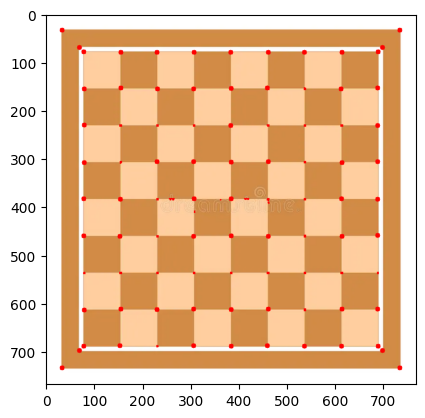

In [ ]:
 # Shi-Tomasi corner detection on the chessboard image (first image)
corners = cv2.goodFeaturesToTrack( gray_chessBoard, maxCorners=64, qualityLevel=0.01, minDistance=10)
corners = np.int32(corners)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(chessBoard, (x, y), 5, (255, 0, 0), -1)
plt.imshow(chessBoard)

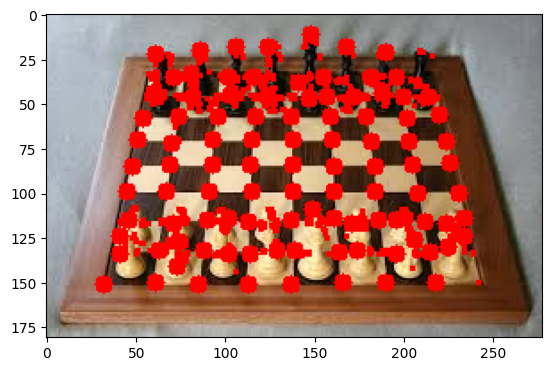

In [35]:
# Shi-Tomasi corner detection on the real chessboard image (second image)
corners = cv2.goodFeaturesToTrack( gray_real_chessBoard, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.int32(corners)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(real_chessBoard, (x, y), 5, (255, 0, 0), -1)
plt.imshow(real_chessBoard)